<a href="https://colab.research.google.com/github/zeqkik/mdc_lambda_projeto_final/blob/main/04_transfer_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [54]:
import os
import pandas as pd
import tensorflow as tf
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report, balanced_accuracy_score, roc_curve, auc
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, BatchNormalization, Dropout, Input

In [55]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [56]:
def predict_and_evaluate(model, features, labels, threeshold = 0.5):

  pred_proba = model.predict(features)
  pred_positive = pred_proba[:, 1]
  pred = np.where(pred_positive > threeshold, 1, 0)
  bal_acc = balanced_accuracy_score(labels, pred)

  print('=='*10)
  print(f'Balanced Accuracy: {bal_acc}')
  print('=='*10)

  report = classification_report(labels, pred, zero_division=0)
  print(report)
  plot_confusion_matrix(labels, pred, ['benigna', 'maligna'], 2)


  return pred_proba, pred, bal_acc, report

In [57]:
def plot_roc_curve(true: np.ndarray, pred: np.ndarray):
    prob_positive = pred[:, 1]

    fpr, tpr, thresholds = roc_curve(true, prob_positive)
    roc_auc = auc(fpr, tpr)

    j_scores = tpr - fpr
    j_index = np.argmax(j_scores)

    optimal_threshold = thresholds[j_index]
    plt.figure(figsize=(8, 6))

    # Curva do Modelo
    plt.plot(fpr, tpr, color='darkorange', lw=2,
             label=f'Curva ROC (AUC = {roc_auc:.4f})')

    # Linha de classificação aleatória
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Aleatório')

    # Ponto do threshold ideal
    plt.plot(fpr[j_index], tpr[j_index], 'ro', markersize=8,
             label=f'Threshold Ideal ({optimal_threshold:.4f})')

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Taxa de Falsos Positivos (1 - Especificidade)')
    plt.ylabel('Taxa de Verdadeiros Positivos (Sensibilidade)')
    plt.title('Curva ROC e Threshold Ótimo para Classificador de Melanoma')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

    return optimal_threshold, roc_auc

In [58]:
IMAGE_SIZE = (224, 224)

def load_and_preprocess(file_path, label):
    """
    Função para carregar a aplicar pré processamento básico em uma imagem.
    Transformação da imagem em tensor e redimensionamento.
    """
    image_binary = tf.io.read_file(file_path)
    image_tf = tf.image.decode_jpeg(image_binary, channels=3)
    image = tf.image.resize(image_tf, IMAGE_SIZE)
    image = tf.cast(image, tf.float32) / 255.0

    return image, label

In [59]:
def augment_data(image, label):
    """
    Função que aplica transformações aleatórias (Data Augmentation) na imagem.
    """
    # Flips e transformações de cor
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta=0.1)
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)
    return image, label


In [60]:
BATCH_SIZE = 32
BASE_DIR = '/content/drive/MyDrive/MDC_data/images/'


In [61]:
# Carregamento o dataframe de rótulos e criação do conjunto de dados como
# Dataset para obter performance otimizada de processamento

train_info = pd.read_csv("/content/drive/MyDrive/MDC_data/train.csv")

train_file_paths = [os.path.join(BASE_DIR, f'{img_path}') for img_path in train_info['path']]

y_train = train_info['target'].values

train_path_ds = tf.data.Dataset.from_tensor_slices((tf.constant(train_file_paths), tf.constant(y_train)))
train_images_ds = train_path_ds.map(load_and_preprocess,
                       num_parallel_calls=tf.data.AUTOTUNE)
train_images_ds_augmented = train_images_ds.shuffle(buffer_size=1024).map(
    augment_data,
    num_parallel_calls=tf.data.AUTOTUNE
)

train_batches = train_images_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
train_batches_augmented = train_images_ds_augmented.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [62]:
val_info = pd.read_csv("/content/drive/MyDrive/MDC_data/val.csv")

val_file_paths = [os.path.join(BASE_DIR, f'{img_path}') for img_path in val_info['path']]

y_val = val_info['target'].values

val_path_ds = tf.data.Dataset.from_tensor_slices((tf.constant(val_file_paths), tf.constant(y_val)))
val_images_ds = val_path_ds.map(load_and_preprocess,
                       num_parallel_calls=tf.data.AUTOTUNE)

val_batches = val_images_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [63]:
def load_and_preprocess_test(file_path):
    """
    Função para carregar a aplicar pré processamento básico em uma imagem.
    Transformação da imagem em tensor e redimensionamento.
    """
    image_binary = tf.io.read_file(file_path)
    image_tf = tf.image.decode_jpeg(image_binary, channels=3)
    image = tf.image.resize(image_tf, IMAGE_SIZE)
    image = tf.cast(image, tf.float32) / 255.0

    return image

In [64]:
def plot_confusion_matrix(y_true, y_pred, class_names, NUM_CLASSES=4):
  cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES))).astype("float")
  cm = cm / cm.sum(axis=1, keepdims=True)

  plt.figure(figsize=(6,5))
  sns.heatmap(
        cm,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        cbar=True,
        linewidths=.5,
        linecolor='black'
    )

  plt.title("Matriz de Confusão Normalizada")
  ticks = np.arange(NUM_CLASSES)
  plt.xticks(ticks + 0.5, class_names, rotation=45, ha="right")
  plt.yticks(ticks + 0.5, class_names, rotation=0)
  plt.ylabel("Verdadeiro")
  plt.xlabel("Predito")
  plt.tight_layout()
  plt.show()

In [65]:
classes = np.unique(y_train)


weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))

In [66]:
class_weights

{np.int64(0): np.float64(0.6083118903716115),
 np.int64(1): np.float64(2.8081491712707183)}

In [67]:
base_model = tf.keras.applications.ResNet50(weights = 'imagenet', include_top = False, input_shape = (224, 224, 3))

# Congelamento de todas camadas
#for layer in model.layers:
#    layer.trainable = False

base_model.trainable = True

#Congelamento de n camadas
for layer in base_model.layers[:-40]:
    layer.trainable = False

model = tf.keras.Sequential([base_model,
                              tf.keras.layers.GlobalAveragePooling2D (),
                              Dropout(rate=0.3),
                              Dense(2, activation = 'softmax')])

input_shape = (None, 224, 224, 3)
model.build(input_shape=input_shape)
model.summary ()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 2)              │         4,098 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,591,810 (90.00 MB)

 Trainable params: 15,835,906 (60.41 MB)

 Non-trainable params: 7,755,904 (29.59 MB)

In [72]:
import keras

#SGD
sgd = tf.keras.optimizers.SGD(learning_rate = 0.001, momentum = 0.9, decay = 0.001)

#Adam
learning_rate = 1e-6 # Uso de baixa taxa de aprendizado
optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

#Early stopping
early = tf.keras.callbacks.EarlyStopping (monitor = 'val_loss', patience = 5, restore_best_weights = True)
f1_score = keras.metrics.F1Score(average = 'macro')

# Compila o modelo (assumindo que 'frozen_model' está definido).
model.compile (loss = 'sparse_categorical_crossentropy', optimizer = optimizer, metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


In [73]:
n_epochs = 10
model.fit(train_batches,
          epochs = n_epochs,
          class_weight = class_weights,
          validation_data = val_batches)


Epoch 1/10
636/636 ━━━━━━━━━━━━━━━━━━━━ 72s 83ms/step - accuracy: 0.7071 - loss: 0.5587 - val_accuracy: 0.7188 - val_loss: 0.5535
Epoch 2/10
636/636 ━━━━━━━━━━━━━━━━━━━━ 39s 61ms/step - accuracy: 0.7195 - loss: 0.5462 - val_accuracy: 0.7368 - val_loss: 0.5299
Epoch 3/10
636/636 ━━━━━━━━━━━━━━━━━━━━ 39s 61ms/step - accuracy: 0.7234 - loss: 0.5356 - val_accuracy: 0.7396 - val_loss: 0.5260
Epoch 4/10
636/636 ━━━━━━━━━━━━━━━━━━━━ 39s 62ms/step - accuracy: 0.7300 - loss: 0.5275 - val_accuracy: 0.7496 - val_loss: 0.5125
Epoch 5/10
636/636 ━━━━━━━━━━━━━━━━━━━━ 39s 61ms/step - accuracy: 0.7360 - loss: 0.5197 - val_accuracy: 0.7016 - val_loss: 0.5674
Epoch 6/10
636/636 ━━━━━━━━━━━━━━━━━━━━ 39s 61ms/step - accuracy: 0.7429 - loss: 0.5090 - val_accuracy: 0.7384 - val_loss: 0.5262
Epoch 7/10
636/636 ━━━━━━━━━━━━━━━━━━━━ 39s 61ms/step - accuracy: 0.7456 - loss: 0.5090 - val_accuracy: 0.7532 - val_loss: 0.5046
Epoch 8/10
636/636 ━━━━━━━━━━━━━━━━━━━━ 39s 61ms/step - accuracy: 0.7469 - loss: 0.4963 - 

79/79 ━━━━━━━━━━━━━━━━━━━━ 11s 89ms/step
Balanced Accuracy: 0.7129536007190203
              precision    recall  f1-score   support

           0       0.91      0.82      0.86      2070
           1       0.41      0.60      0.49       430

    accuracy                           0.78      2500
   macro avg       0.66      0.71      0.68      2500
weighted avg       0.82      0.78      0.80      2500



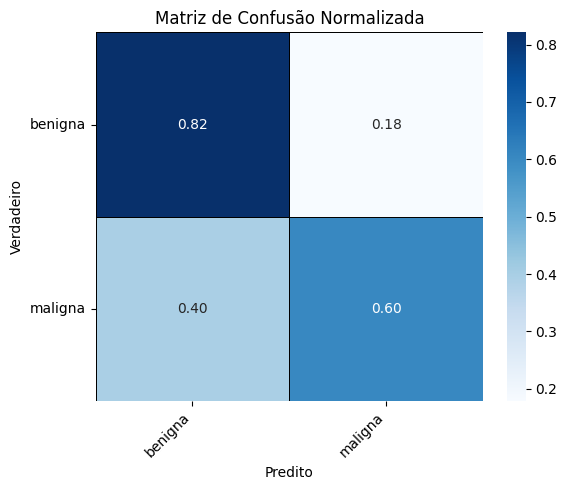

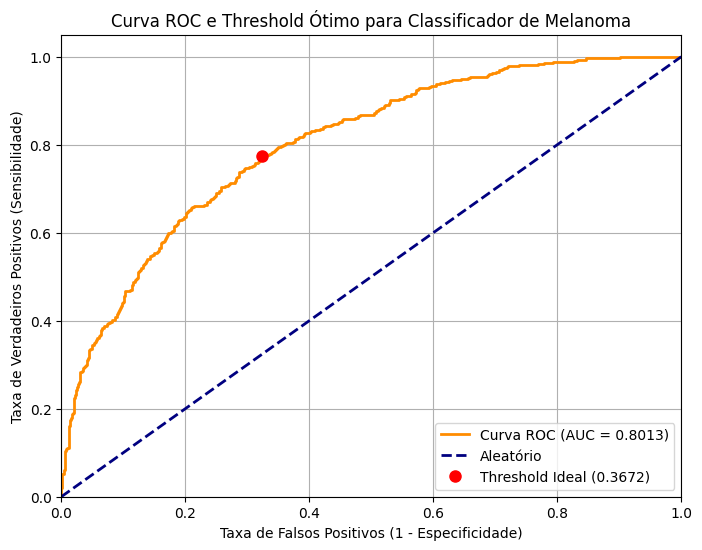

In [74]:
val_pred_proba, val_pred, val_bal_acc, val_report = predict_and_evaluate(model, val_batches, y_val)
optimal_threshold, roc_auc = plot_roc_curve(y_val, val_pred_proba)


79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step
Balanced Accuracy: 0.7244523087293563
              precision    recall  f1-score   support

           0       0.93      0.68      0.79      2070
           1       0.33      0.77      0.46       430

    accuracy                           0.69      2500
   macro avg       0.63      0.72      0.62      2500
weighted avg       0.83      0.69      0.73      2500



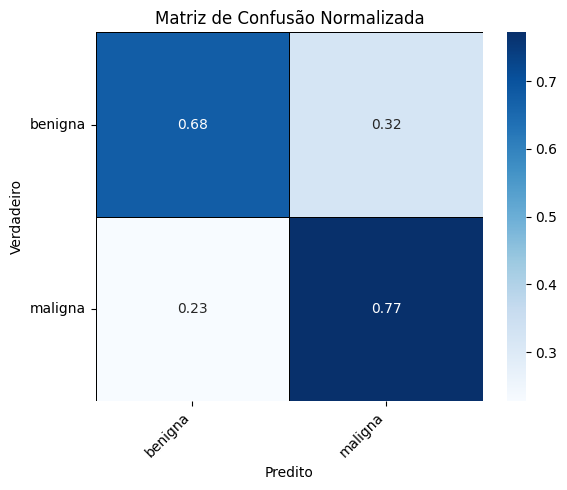

In [75]:
val_pred_proba, val_pred, val_bal_acc, val_report = predict_and_evaluate(model, val_batches, y_val, optimal_threshold)


In [79]:
import os

model_save_dir = os.path.join(BASE_DIR, 'models')
os.makedirs(model_save_dir, exist_ok=True)

model_path = os.path.join(model_save_dir, 'best_model_1012.keras')
model.save(model_path)

threshold_path = os.path.join(model_save_dir, 'optimal_threshold_1012.txt')
with open(threshold_path, 'w') as f:
    f.write(str(optimal_threshold))


In [80]:
base_model.trainable = False

In [81]:

model_v2 = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(256, activation='relu'),

    tf.keras.layers.Dropout(rate=0.3),

    tf.keras.layers.Dense(2, activation='softmax')
])

In [88]:
optimizer_v2 = tf.keras.optimizers.Adam(learning_rate=learning_rate)

model_v2.compile(loss = 'sparse_categorical_crossentropy', optimizer = optimizer_v2, metrics=['accuracy'])

In [ ]:

n_epochs = 30
model_v2.fit(train_batches,
          epochs = n_epochs,
          callbacks = early,
          class_weight = class_weights,
          validation_data = val_batches)


Epoch 1/30


/usr/local/lib/python3.12/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


636/636 ━━━━━━━━━━━━━━━━━━━━ 303s 473ms/step - accuracy: 0.7941 - loss: 0.9343 - val_accuracy: 0.6904 - val_loss: 0.6561
Epoch 2/30
636/636 ━━━━━━━━━━━━━━━━━━━━ 306s 482ms/step - accuracy: 0.5901 - loss: 0.6759 - val_accuracy: 0.6996 - val_loss: 0.6327
Epoch 3/30
636/636 ━━━━━━━━━━━━━━━━━━━━ 307s 483ms/step - accuracy: 0.6664 - loss: 0.6237 - val_accuracy: 0.7404 - val_loss: 0.5977
Epoch 4/30
636/636 ━━━━━━━━━━━━━━━━━━━━ 311s 489ms/step - accuracy: 0.6963 - loss: 0.5967 - val_accuracy: 0.7408 - val_loss: 0.5827
Epoch 5/30
636/636 ━━━━━━━━━━━━━━━━━━━━ 310s 487ms/step - accuracy: 0.7200 - loss: 0.5709 - val_accuracy: 0.7400 - val_loss: 0.5706
Epoch 6/30
636/636 ━━━━━━━━━━━━━━━━━━━━ 311s 489ms/step - accuracy: 0.7286 - loss: 0.5524 - val_accuracy: 0.7388 - val_loss: 0.5624
Epoch 7/30
636/636 ━━━━━━━━━━━━━━━━━━━━ 310s 487ms/step - accuracy: 0.7408 - loss: 0.5405 - val_accuracy: 0.7416 - val_loss: 0.5523
Epoch 8/30
636/636 ━━━━━━━━━━━━━━━━━━━━ 305s 480ms/step - accuracy: 0.7438 - loss: 0.53